# DNA sequencing: bulk and single cell

We grow one tumour, look at exactly what is in it, then sequence it the way a lab would — bulk
whole-genome, a targeted panel, and single-cell DNA — and check every readout against the truth.

The through-line: **a bulk sample is a mixture, and a DNA read count is three things multiplied
together** — how many cells carry the variant, how many copies of the locus they carry it on, and
how much normal tissue is diluting them. Pull those apart and the numbers make sense. Leave them
mixed and the clonal peak lands in the wrong place.

## 1. Ground truth

The substrate is a centimetre-scale duct-and-stroma lesion: a single transformed cell in one duct
that spread to its neighbours, broke through the basement membrane and invaded the stroma. It takes
about two minutes to grow.

`to_anndata` packs the whole thing into one `AnnData` — expression in `X`, the SNV and copy-number
matrices in `layers`, clone / cell type / coordinates in `obs`, gene roles in `var`.

In [1]:
%matplotlib inline
import os, sys, warnings
sys.path.insert(0, os.path.abspath("."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

import base_sim as B
from iscc.integrations import to_anndata, to_lineage_tree, clones_from_clades, clone_summary
from iscc.sample import Resection
from iscc.data.dna import bulkDNA, scDNA
from iscc.data import estimate_dna, estimate_dna_from_assay

warnings.filterwarnings("ignore")
np.random.seed(0)
MIN_CELLS = 50           # smallest lineage clade that counts as its own clone

tumor = B.grow_base_tumor()
adata = to_anndata(tumor, layers=["cell_snv", "cell_cnv"], clone_min_cells=MIN_CELLS)
clones = clones_from_clades(tumor, min_cells=MIN_CELLS)

genes = adata.var_names.to_numpy()
is_cancer = (adata.obs["cell_type"] == "cancer").to_numpy()
print(f"{tumor.get_tumor_size():,} cells in the lesion ({tumor.get_cancer_size():,} cancer), "
      f"{adata.n_obs:,} materialised for assay")
print(adata.obs["cell_type"].value_counts().to_string())
print(f"\ncancer-cell mean ploidy {adata.layers['cell_cnv'][is_cancer].mean():.2f}, "
      f"{(adata.layers['cell_cnv'][is_cancer] != 2).mean():.0%} of the genome altered, "
      f"{adata.obs['is_wgd'][is_cancer].mean():.0%} of cells past a whole-genome doubling")

345,990 cells in the lesion (80,394 cancer), 7,917 materialised for assay
cell_type
stromal       5877
cancer        1842
epithelial     198

cancer-cell mean ploidy 3.00, 58% of the genome altered, 48% of cells past a whole-genome doubling


### The variant layers the tumour started with

Two layers exist before growth, and most of section 3 turns on them.

* **`tumor.truncal_sites`** — what the founder cell already carried when it transformed. Every
  cancer cell inherits them, so these are the tumour's **clonal** mutations.
* **`tumor.germline_sites`** — the patient's inherited variants, in **every** cell including the
  normal ones. The heterozygous ones sit at one copy of two, so they read at ~50% of the reads
  whatever the tumour/normal mixture is. That is the purity anchor.

We fold both, plus each locus's true multiplicity and cancer-cell fraction, straight into
`adata.var` so every later section can index the truth by locus name.

In [2]:
snv = adata.layers["cell_snv"]          # per-cell alt fraction at each locus
cnv = adata.layers["cell_cnv"]          # per-cell total copy number
sel = tumor.selection

def mask(idx):
    m = np.zeros(adata.n_vars, bool); m[np.asarray(idx, int)] = True; return m

zyg = np.asarray(tumor.germline_zygosity)
adata.var["truncal"] = mask(tumor.truncal_sites)
adata.var["truncal_driver"] = mask(np.asarray(tumor.truncal_sites)[np.asarray(tumor.truncal_is_driver)])
adata.var["germline_het"] = mask(np.asarray(tumor.germline_sites)[zyg == "het"])
adata.var["germline_hom"] = mask(np.asarray(tumor.germline_sites)[zyg == "hom"])
adata.var["driver"] = mask(np.concatenate([sel.get_oncogenes(), sel.get_tsgs()]))
adata.var["trait"] = mask(np.concatenate([sel.get_breach(), sel.get_stromal_survival(),
                                          sel.get_dispersal_genes(), sel.get_immune_resistant(),
                                          sel.get_treatment_resistant()]))

# per-locus truth: how many cancer cells carry the variant, and on how many copies
carrier = (snv > 0) & is_cancer[:, None]
n_carrier = carrier.sum(0)
adata.var["ccf_true"] = n_carrier / is_cancer.sum()
adata.var["multiplicity"] = np.where(n_carrier > 0, (snv * cnv * carrier).sum(0) / np.maximum(n_carrier, 1), np.nan)
adata.var["somatic"] = (n_carrier > 0) & ~adata.var["germline_het"] & ~adata.var["germline_hom"]

V = adata.var
print(f"{int(V.truncal.sum())} truncal sites ({int(V.truncal_driver.sum())} of them in driver genes), "
      f"{int(V.germline_het.sum())} germline hets, {int(V.germline_hom.sum())} germline homs")
print(f"truncal sites: carried by {V.ccf_true[V.truncal].mean():.1%} of cancer cells "
      f"on {V.multiplicity[V.truncal].mean():.2f} copies on average")
print(f"other somatic sites: {int((V.somatic & ~V.truncal).sum())}, median cancer-cell fraction "
      f"{V.ccf_true[V.somatic & ~V.truncal].median():.3f}")

42 truncal sites (2 of them in driver genes), 27 germline hets, 13 germline homs
truncal sites: carried by 96.6% of cancer cells on 1.55 copies on average
other somatic sites: 5899, median cancer-cell fraction 0.003


### The true phylogeny

A **clone** is a clade of the true lineage tree holding at least `MIN_CELLS` sampled cells
(`clones_from_clades`). Cells on the ancestral backbone, above every clade, are labelled `other`.
The tree below is the real genealogy of 250 sampled cancer cells — not an inference.

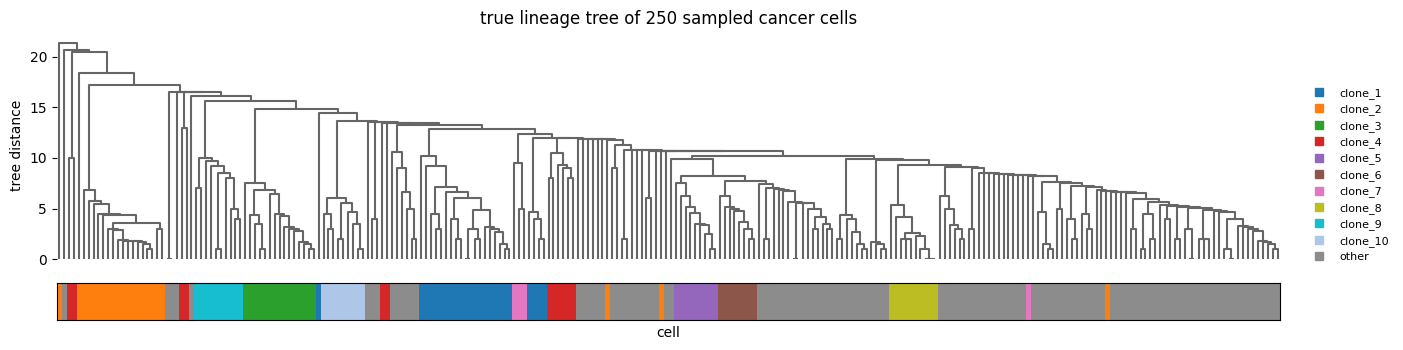

clone
other       966
clone_1     234
clone_2     126
clone_3      90
clone_4      81
clone_5      71
clone_6      65
clone_7      55
clone_8      53
clone_9      51
clone_10     50


In [3]:
rng = np.random.default_rng(0)
cancer_ids = adata.obs_names[is_cancer]
cells250 = rng.choice(cancer_ids, size=250, replace=False)

tree = to_lineage_tree(tumor)
D = tree.distance_matrix(ids=adata.obs.loc[cells250, "genotype"])
Z = linkage(squareform(D, checks=False), method="average")

labels = clones.reindex(cells250).astype(str).values
names = [c for c in clones.cat.categories if c != "other" and (labels == c).any()]
wheel = [plt.get_cmap("tab20").colors[i] for i in (0, 2, 4, 6, 8, 10, 12, 16, 18, 1, 3, 5)]
palette = dict(zip(names, wheel))
palette["other"] = (0.55, 0.55, 0.55)
cell_colors = np.array([palette[l] for l in labels])

fig, (ax, cax) = plt.subplots(2, 1, figsize=(13, 3.6), height_ratios=[6, 1])
dn = dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, link_color_func=lambda k: "0.4")
order = dn["leaves"]
ax.set_ylabel("tree distance"); ax.set_title("true lineage tree of 250 sampled cancer cells")
ax.set_xticks([])
for s in ax.spines.values(): s.set_visible(False)
cax.imshow(cell_colors[order][None, :, :], aspect="auto")
cax.set_yticks([]); cax.set_xticks([]); cax.set_xlabel("cell")
handles = [plt.Line2D([], [], marker="s", ls="", color=palette[n], label=n) for n in names + ["other"]]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.08, 0.5), frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(clones.value_counts().loc[lambda s: s > 0].to_string())

Ten clones, the biggest holding an eighth of the cancer cells. Half the cells sit in `other`:
in a growing, spatially structured tumour much of the population is still ancestral backbone rather
than a well-separated subclone.

### SNV and copy number, with the tree down the side

Same cells, same order, both matrices. Loci are the most variable SNV sites plus every truncal and
clone-defining one, laid out along the genome; driver and trait genes are ticked underneath.

199 SNV loci shown; 21 clone-defining sites in the tumour (10 of them in driver or trait genes)


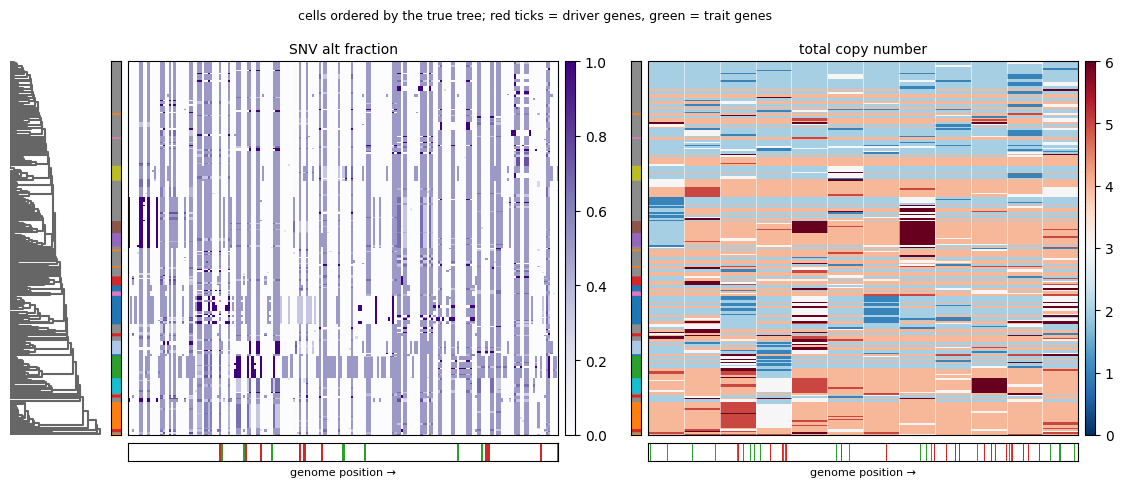

In [4]:
# clone-defining sites: variants in a clone's founding genotype that the tumour founder lacked
summary = clone_summary(tumor, clones)
founder_snv = tumor.genotypes[tumor.founder_id].get_snvs() > 0
defining = {lab: np.flatnonzero((tumor.genotypes[str(g)].get_snvs() > 0) & ~founder_snv)
            for lab, g in summary["genotype"].items() if not pd.isna(g)}
adata.var["clone_defining"] = mask(np.unique(np.concatenate([v for v in defining.values() if len(v)])))

# loci for the SNV heatmap
keep = np.flatnonzero(V.truncal | V.clone_defining)
var_rank = np.argsort(-snv[is_cancer].var(0))
loci = np.union1d(keep, var_rank[:180])
print(f"{len(loci)} SNV loci shown; {int(V.clone_defining.sum())} clone-defining sites in the tumour "
      f"({int((V.clone_defining & (V.driver | V.trait)).sum())} of them in driver or trait genes)")

pos = adata.obs_names.get_indexer(cells250)[order]

def heatmap(ax, M, title, **kw):
    im = ax.imshow(M, aspect="auto", origin="lower", interpolation="nearest", **kw)
    ax.set_title(title, fontsize=10); ax.set_yticks([])
    return im

fig = plt.figure(figsize=(14, 5.2))
gs = fig.add_gridspec(2, 8, width_ratios=[1.1, 0.12, 5, 0.12, 0.5, 0.12, 5, 0.12],
                      height_ratios=[20, 1], wspace=0.05, hspace=0.04)
axd = fig.add_subplot(gs[0, 0])
dendrogram(Z, ax=axd, orientation="left", no_labels=True, color_threshold=0,
           link_color_func=lambda k: "0.4")
axd.set_xticks([]); axd.set_yticks([]); axd.invert_xaxis()
for s in axd.spines.values(): s.set_visible(False)
for col in (1, 5):
    a = fig.add_subplot(gs[0, col]); a.imshow(cell_colors[order][:, None, :], aspect="auto", origin="lower")
    a.set_xticks([]); a.set_yticks([])

a1 = fig.add_subplot(gs[0, 2])
im1 = heatmap(a1, snv[np.ix_(pos, loci)], "SNV alt fraction", cmap="Purples", vmin=0, vmax=1)
a1.set_xticks([])
a2 = fig.add_subplot(gs[0, 6])
im2 = heatmap(a2, cnv[pos], "total copy number", cmap="RdBu_r", vmin=0, vmax=6)
a2.set_xticks([])
for s in np.arange(1, 12) * 500:
    a2.axvline(s, color="w", lw=0.4)
for im, col in ((im1, 3), (im2, 7)):
    fig.colorbar(im, cax=fig.add_subplot(gs[0, col]))

# driver / trait positions ticked under each heatmap
for ax, idx in ((fig.add_subplot(gs[1, 2]), loci), (fig.add_subplot(gs[1, 6]), np.arange(adata.n_vars))):
    role = np.where(V.driver.values[idx], 1, np.where(V.trait.values[idx], 2, 0))
    ax.imshow(role[None, :], aspect="auto", cmap=ListedColormap(["white", "#d62728", "#2ca02c"]),
              vmin=0, vmax=2, interpolation="nearest")
    ax.set_yticks([]); ax.set_xticks([]); ax.set_xlabel("genome position →", fontsize=8)
fig.suptitle("cells ordered by the true tree; red ticks = driver genes, green = trait genes", fontsize=9)
plt.show()

The SNV panel is striped: columns present in every cell (the truncal sites) alongside
sparse, lineage-specific variants that stop at a clade boundary. The copy-number panel is the opposite: almost every cell has its own
gains and losses, and the clones are not clean blocks. That subclonality is what makes the bulk
copy-number profile in section 3 come out flat.

### Where the clones sit

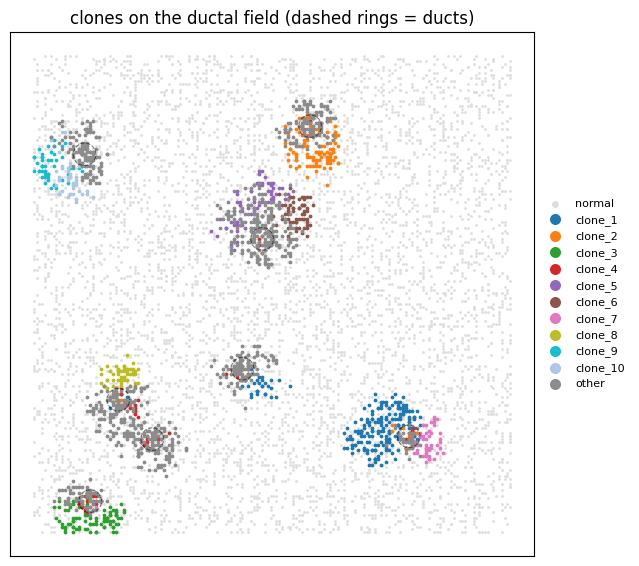

In [5]:
xy = adata.obsm["spatial"]
fig, ax = plt.subplots(figsize=(6.4, 6.2))
ax.scatter(*xy[~is_cancer].T, s=1, c="0.87", label="normal")
for n in names:
    m = (clones.reindex(adata.obs_names).astype(str).values == n)
    ax.scatter(*xy[m].T, s=3, color=palette[n], label=n)
m = (clones.reindex(adata.obs_names).astype(str).values == "other")
ax.scatter(*xy[m].T, s=3, color=palette["other"], label="other")
B.draw_glands(ax, tumor)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("clones on the ductal field (dashed rings = ducts)")
ax.legend(markerscale=4, fontsize=8, frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(); plt.show()

Clones are spatially clustered — a subclone is a patch, because a tumour cell's descendants
stay near it.

### What each clone carries

In [6]:
cols = ["n_cells", "n_genotypes", "division_rate", "traits"]
display(summary[cols].round(3))
for lab, row in summary.iterrows():
    if pd.isna(row["traits"]):
        continue
    n = len(defining.get(lab, []))
    print(f"{lab}: {row['n_cells']} cells, {row['traits']}, {n} clone-defining SNVs")

,n_cells,n_genotypes,division_rate,traits
clone,,,,
clone_1,234,196,0.767,2 oncogene
clone_2,126,118,0.847,2 oncogene
clone_3,90,77,0.950,"3 oncogene, 1 TSG"
clone_4,81,76,0.841,2 oncogene
clone_5,71,57,0.950,"3 oncogene, 1 breach"
clone_6,65,60,0.950,2 oncogene
clone_7,55,38,0.847,2 oncogene
clone_8,53,32,0.380,"3 oncogene, 2 immune-resistance, 1 breach"
clone_9,51,44,0.921,"2 oncogene, 1 immune-resistance"


clone_1: 234 cells, 2 oncogene, 0 clone-defining SNVs
clone_2: 126 cells, 2 oncogene, 0 clone-defining SNVs
clone_3: 90 cells, 3 oncogene, 1 TSG, 2 clone-defining SNVs
clone_4: 81 cells, 2 oncogene, 0 clone-defining SNVs
clone_5: 71 cells, 3 oncogene, 1 breach, 1 clone-defining SNVs
clone_6: 65 cells, 2 oncogene, 0 clone-defining SNVs
clone_7: 55 cells, 2 oncogene, 0 clone-defining SNVs
clone_8: 53 cells, 3 oncogene, 2 immune-resistance, 1 breach, 11 clone-defining SNVs
clone_9: 51 cells, 2 oncogene, 1 immune-resistance, 2 clone-defining SNVs
clone_10: 50 cells, 3 oncogene, 1 immune-resistance, 1 breach, 9 clone-defining SNVs


All ten carry the two transforming oncogene hits the founder had. What separates them is what
came after: `breach` (the mutation that lets a cell cross the basement membrane), immune resistance,
an extra oncogene or tumour suppressor. Half of them have **no** clone-defining SNV at all — they
differ from the trunk by copy number only. Remember that when section 4 asks what a panel can see.

## 2. Dissociation

`Resection` cuts the specimen. `dissociate` takes the whole lesion, at full depth, and returns the
per-cell tables the sequencing assays consume. No slicing — that is for the spatial assays, which
keep the tissue architecture; a dissociation throws the coordinates away.

`install=True` makes this sample the tumour's own cell table, so the clone labels and the assays
refer to exactly the same cells.

In [7]:
sample = Resection(tumor).dissociate(install=True)
purity_true = float(is_cancer.mean())
print(f"{sample['cell_snv'].shape[0]:,} cells x {sample['cell_snv'].shape[1]:,} loci")
print(f"true purity (cancer fraction of the pool): {purity_true:.3f}")
print(adata.obs["cell_type"].value_counts(normalize=True).round(3).to_string())

7,917 cells x 6,000 loci
true purity (cancer fraction of the pool): 0.233
cell_type
stromal       0.742
cancer        0.233
epithelial    0.025


A whole-lesion dissociation is mostly stroma. **Purity is 23%** — three quarters of the DNA
in the tube is normal. Everything in section 3 follows from that.

## 3. Bulk whole-genome sequencing

`bulkDNA` pools every cell into one library. Coverage at a locus is proportional to the pooled copy
number times a per-locus capture efficiency, and the alt count is a binomial draw at the pooled alt
fraction with a sequencing-error floor.

In [8]:
wgs = bulkDNA(breadth="wgs", seed=1, mu_depth=100.0).run(sample, germline_sites=tumor.germline_sites)
h = wgs.hypers.to_dict()
print(pd.Series({"loci assayed": len(wgs.observed_data),
                 "cells pooled": wgs.n_cells_pooled,
                 "library size (reads)": int(h["mu_depth"] * len(wgs.observed_data)),
                 "mean depth": h["mu_depth"],
                 "sequencing error rate": h["error_rate"],
                 "FFPE C>T rate": h["ffpe_ct_rate"],
                 "read-spread concentration (kappa)": h["kappa"],
                 "GC-curve sigma": h["gc_curve_sigma"],
                 "capture sigma": h["capture_sigma"],
                 "true purity": round(wgs.purity, 3)}).to_string())
wgs.observed_data.head()

loci assayed                           6000.000
cells pooled                           7917.000
library size (reads)                 600000.000
mean depth                              100.000
sequencing error rate                     0.001
FFPE C>T rate                             0.000
read-spread concentration (kappa)      2000.000
GC-curve sigma                            0.200
capture sigma                             0.000
true purity                               0.233


,coverage,alt_counts,vaf,true_cn,true_alt_fraction,log2_ratio,segment,gc,mappability,is_germline
locus,,,,,,,,,,
G_0_0,662,1,0.001511,2.169003,0.000524,3.730658,0,0.558192,0.989401,False
G_0_1,24,0,0.000000,2.169003,0.000524,-1.044669,0,0.376023,0.971859,False
G_0_2,22,0,0.000000,2.169003,0.000408,-1.180851,0,0.414275,0.955328,False
G_0_3,0,0,0.000000,2.169003,0.000349,NaN,0,0.405341,0.963960,False
G_0_4,14,0,0.000000,2.169003,0.000524,-1.094778,0,0.263528,0.685134,False


### Coverage, log2 ratio and VAF across depths

Standard clinical bulk WGS runs at ~30x. Deep WGS is 60–100x. We sweep 10x (too shallow to call
anything), 30x, 60x and 100x. A locus is *called* when it has at least 20 reads, at least 3 of them
alt, and a VAF of at least 5% — the usual floor, which throws away the sequencing-error background.

Copy-number callers never look at single loci; they bin. The top row shows the raw per-locus log2
ratio in grey, the same data binned 100 loci at a time in black, and the truth in red.

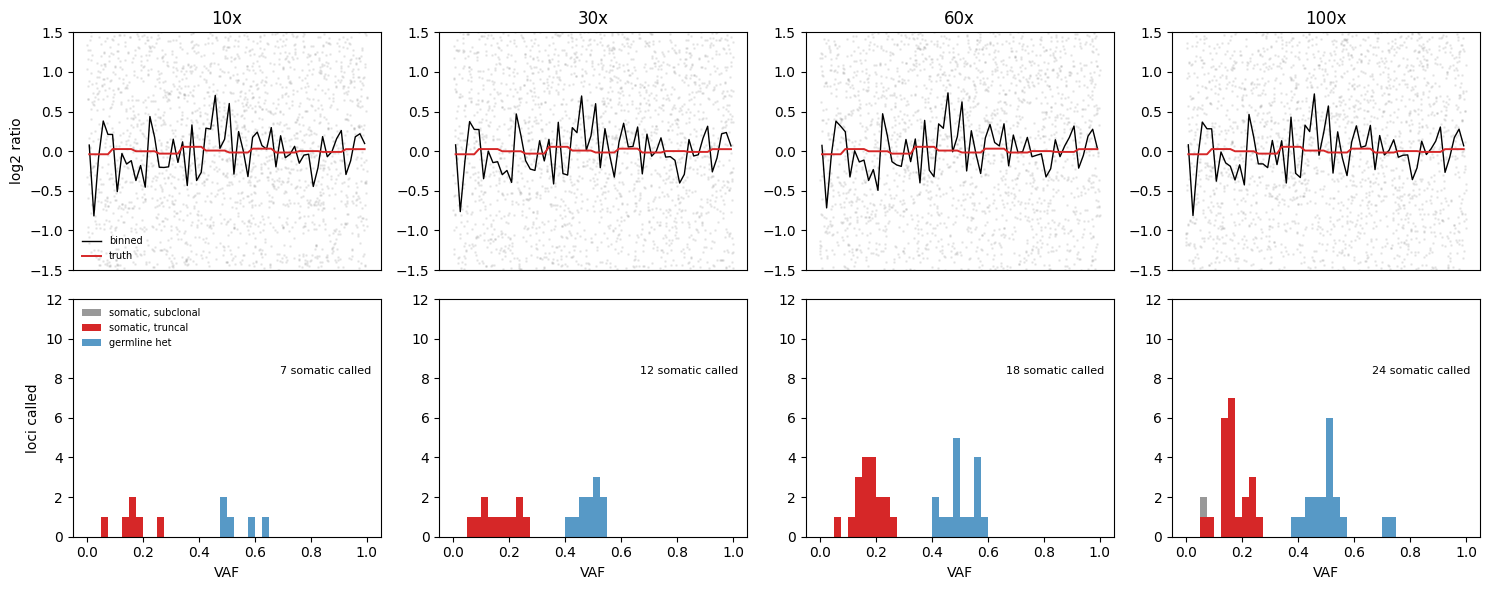

at 100x: germline het VAF median 0.500, germline hom 1.000, truncal 0.149

pooled copy number by segment ranges 2.17-2.32 — essentially flat
cancer-cell-only copy number by segment ranges 2.73-3.35

segment log2: true signal spans 0.09, measurement scatter is 0.13 — the noise is bigger than the signal


In [9]:
depths = [10, 30, 60, 100]
runs = {d: bulkDNA(breadth="wgs", seed=1, mu_depth=float(d)).run(sample, germline_sites=tumor.germline_sites)
        for d in depths}

BIN = 100
b = np.arange(adata.n_vars) // BIN
centre = (np.arange(b.max() + 1) + 0.5) * BIN
def binmean(x):
    return np.bincount(b, np.asarray(x, float)) / np.bincount(b)
true_l2 = np.log2(binmean(runs[100].observed_data["true_cn"]) / np.median(binmean(runs[100].observed_data["true_cn"])))

fig, axes = plt.subplots(2, len(depths), figsize=(15, 6))
for j, d in enumerate(depths):
    od = runs[d].observed_data
    v = V.loc[od.index]
    ax = axes[0, j]
    ax.scatter(np.arange(len(od)), od["log2_ratio"], s=1, alpha=0.12, c="0.5")
    corr = binmean(od["coverage"].values / runs[d].batch.efficiency)
    ax.plot(centre, np.log2(corr / np.median(corr)), "k-", lw=1, label="binned")
    ax.plot(centre, true_l2, "C3-", lw=1.4, label="truth")
    ax.set_ylim(-1.5, 1.5); ax.set_title(f"{d}x"); ax.set_xticks([])
    if j == 0: ax.set_ylabel("log2 ratio"); ax.legend(fontsize=7, frameon=False, loc="lower left")

    called = (od["coverage"] >= 20) & (od["alt_counts"] >= 3) & (od["vaf"] >= 0.05)
    ax = axes[1, j]
    bins = np.linspace(0, 1, 41)
    ax.hist(od.loc[called & v.somatic.values & ~v.truncal.values, "vaf"], bins=bins,
            color="0.6", label="somatic, subclonal")
    ax.hist(od.loc[called & v.truncal.values, "vaf"], bins=bins, color="C3", label="somatic, truncal")
    ax.hist(od.loc[called & v.germline_het.values, "vaf"], bins=bins, color="C0", alpha=0.75,
            label="germline het")
    ax.set_xlabel("VAF"); ax.set_ylim(0, 12)
    if j == 0: ax.set_ylabel("loci called"); ax.legend(fontsize=7, frameon=False, loc="upper left")
    ax.text(0.97, 0.72, f"{int((called & v.somatic.values).sum())} somatic called", ha="right",
            va="top", transform=ax.transAxes, fontsize=8)
plt.tight_layout(); plt.show()

od = runs[100].observed_data; v = V.loc[od.index]
print(f"at 100x: germline het VAF median {od.loc[v.germline_het.values, 'vaf'].median():.3f}, "
      f"germline hom {od.loc[v.germline_hom.values, 'vaf'].median():.3f}, "
      f"truncal {od.loc[v.truncal.values, 'vaf'].median():.3f}")
print(f"\npooled copy number by segment ranges {od.groupby('segment').true_cn.mean().min():.2f}-"
      f"{od.groupby('segment').true_cn.mean().max():.2f} — essentially flat")
print(f"cancer-cell-only copy number by segment ranges "
      f"{pd.Series(cnv[is_cancer].mean(0)).groupby(V.segment.values).mean().min():.2f}-"
      f"{pd.Series(cnv[is_cancer].mean(0)).groupby(V.segment.values).mean().max():.2f}")
segl2 = np.log2(od.groupby("segment").true_cn.mean() / od.true_cn.median())
seg_obs = od.assign(c=od.coverage / runs[100].batch.efficiency).groupby("segment").c.mean()
seg_obs = np.log2(seg_obs / seg_obs.median())
print(f"\nsegment log2: true signal spans {segl2.max() - segl2.min():.2f}, "
      f"measurement scatter is {(seg_obs - segl2).std():.2f} — the noise is bigger than the signal")

**The VAF plot.** Two peaks, and neither is where a naive reading expects.

* The **germline heterozygous** sites sit at 0.5. They are on one of two copies in *every* cell, so
  the mixture cannot move them. That is the ruler.
* The **truncal** somatic sites — every cancer cell has them — pile up near 0.15, not 0.5, because
  only 23% of the DNA is cancer.
* Nearly nothing else is called. Subclonal variants in this tumour are carried by a fraction of a
  fraction; at 23% purity and 100x they are below the noise. Bulk WGS sees the trunk and little else.
* The two truncal **driver** hits sit inside the same peak as the 40 truncal **passengers**. VAF
  measures *how many cells carry a variant*, not whether it does anything. Nothing in this plot
  separates a driver from a passenger.

**The log2 ratio.** The truth (red) is flat, even though 58% of each cancer genome is altered. The
copy-number changes here are subclonal — almost every cell has a different set — so pooling averages
them out, and the 77% normal DNA flattens what is left. The binned measurement (black) barely
improves from 10x to 100x, because its scatter comes from how *unevenly* reads spread over the
genome, not from how many there are. Aggregate all the way to whole chromosome segments and the
measurement scatter is still larger than the real signal. Section 5 recovers these CNAs one cell at
a time.

### Normal contamination and cancer-cell fraction

A variant's VAF confounds three things. Unpick them:

$$\text{VAF} \;=\; \frac{\text{CCF} \times m \times \rho}{\overline{CN}}$$

with $\rho$ the purity, $m$ the **multiplicity** (how many copies of the locus carry the mutation),
$\overline{CN}$ the pooled mean copy number at that locus, and CCF the cancer-cell fraction — the
thing we actually want. Rearranged, $\text{CCF} = \text{VAF}\cdot\overline{CN} / (\rho\, m)$.

Purity comes from the data via the germline anchor. A germline het is on one copy of two in every
cell, so it reads at 0.5 whatever the mixture — that is the ruler. Read the clonal somatic peak
against it and you get $\rho$, provided the clonal variants really are on one copy each.

germline-het anchor 0.505    clonal somatic peak 0.158
purity, one copy per variant assumed : 0.313
purity, corrected for multiplicity   : 0.236
true purity                          : 0.233


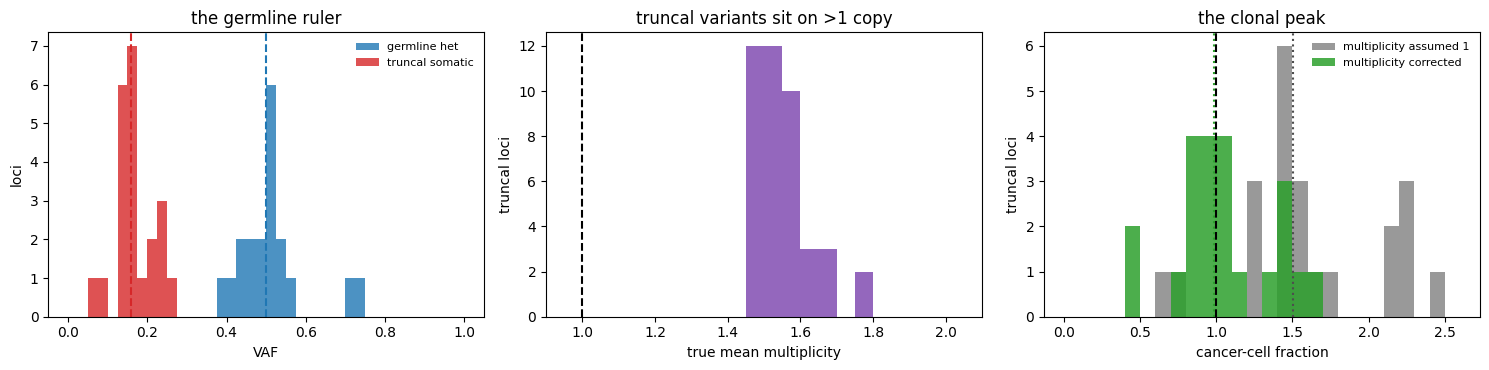


clonal peak, multiplicity assumed 1 : 1.51
clonal peak, multiplicity corrected: 0.99
truth (fraction of cancer cells carrying a truncal site): 0.97
mean true multiplicity at truncal sites: 1.55 (48% of cancer cells are post-doubling)


In [10]:
od = runs[100].observed_data; v = V.loc[od.index]
called = (od["coverage"] >= 20) & (od["alt_counts"] >= 3)

# read the clonal somatic peak against the germline-het ruler, at loci of median pooled copy number
balanced = np.abs(od["true_cn"] - od["true_cn"].median()) < 0.05
anchor = od.loc[called & v.germline_het.values & balanced, "vaf"].median()
peak = od.loc[called & v.truncal.values & balanced, "vaf"].median()
cn_pool = od["true_cn"].median()
m_truncal = v.multiplicity[v.truncal.values].mean()
ccf_truncal = v.ccf_true[v.truncal.values].mean()
print(f"germline-het anchor {anchor:.3f}    clonal somatic peak {peak:.3f}")
print(f"purity, one copy per variant assumed : {peak / anchor:.3f}")
print(f"purity, corrected for multiplicity   : {peak * cn_pool / (ccf_truncal * m_truncal):.3f}")
print(f"true purity                          : {wgs.purity:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
ax = axes[0]
ax.hist(od.loc[called & v.germline_het.values, "vaf"], bins=np.linspace(0, 1, 41), color="C0",
        alpha=0.8, label="germline het")
ax.hist(od.loc[called & v.truncal.values, "vaf"], bins=np.linspace(0, 1, 41), color="C3",
        alpha=0.8, label="truncal somatic")
ax.axvline(0.5, color="C0", ls="--"); ax.axvline(peak, color="C3", ls="--")
ax.set_xlabel("VAF"); ax.set_ylabel("loci"); ax.legend(fontsize=8, frameon=False)
ax.set_title("the germline ruler")

ax = axes[1]
ax.hist(v.multiplicity[v.truncal.values].dropna(), bins=np.linspace(0.9, 2.1, 25), color="C4")
ax.axvline(1, color="k", ls="--")
ax.set_xlim(0.9, 2.1); ax.set_xlabel("true mean multiplicity"); ax.set_ylabel("truncal loci")
ax.set_title("truncal variants sit on >1 copy")

ccf_naive = od["vaf"] * od["true_cn"] / wgs.purity
ccf_corr = ccf_naive / v["multiplicity"].fillna(1.0)
ax = axes[2]
bins = np.linspace(0, 2.6, 27)
sel_ = called & v.truncal.values
ax.hist(ccf_naive[sel_], bins=bins, color="0.6", label="multiplicity assumed 1")
ax.hist(ccf_corr[sel_], bins=bins, color="C2", alpha=0.85, label="multiplicity corrected")
ax.axvline(ccf_naive[sel_].median(), color="0.3", ls=":")
ax.axvline(ccf_corr[sel_].median(), color="C2", ls=":")
ax.axvline(1, color="k", ls="--")
ax.set_xlabel("cancer-cell fraction"); ax.set_ylabel("truncal loci")
ax.legend(fontsize=8, frameon=False); ax.set_title("the clonal peak")
plt.tight_layout(); plt.show()

print(f"\nclonal peak, multiplicity assumed 1 : {ccf_naive[sel_].median():.2f}")
print(f"clonal peak, multiplicity corrected: {ccf_corr[sel_].median():.2f}")
print(f"truth (fraction of cancer cells carrying a truncal site): {v.ccf_true[v.truncal.values].mean():.2f}")
print(f"mean true multiplicity at truncal sites: {v.multiplicity[v.truncal.values].mean():.2f} "
      f"({adata.obs['is_wgd'][is_cancer].mean():.0%} of cancer cells are post-doubling)")

**The clonal peak does not land at 1.0.** Assume one mutated copy per locus and it comes out
around 1.5. The purity read the same naive way overshoots by the same factor — 0.31 against a true
0.23.

That is not an error, it is **multiplicity**. Roughly half the cancer cells here have been through a
whole-genome doubling, and a doubling copies the truncal variants along with everything else, so a
truncal site sits on ~1.55 copies on average rather than 1. Divide by the true multiplicity and both
numbers land: the clonal peak just under 1.0, purity within a hundredth of the truth.

Real callers (ABSOLUTE, MutationTimeR) have to *infer* multiplicity from the allele-specific copy
number, jointly with purity, and then decide per variant whether it predates or postdates the
doubling. Get it wrong and you report a clonal variant as super-clonal, or split one clone into two.
Here the simulator knows the answer, so the correction can be checked instead of assumed.

## 4. Targeted panel

Same tube, same cells, ~50x the depth on 30 loci instead of 30x on all of them. A real panel
targets recurrent cancer genes, so we build one from driver and trait genes and include the
tumour's two truncal driver hits — the best case for a panel.

In [11]:
pool = np.unique(np.concatenate([np.flatnonzero(V.driver), np.flatnonzero(V.trait)]))
truncal_drivers = np.flatnonzero(V.truncal_driver)
rest = np.random.default_rng(7).choice(np.setdiff1d(pool, truncal_drivers), 28, replace=False)
panel_idx = np.sort(np.concatenate([truncal_drivers, rest]))
panel = bulkDNA(breadth="panel", seed=1, target_genes=list(genes[panel_idx])).run(
    sample, germline_sites=tumor.germline_sites)

hp = panel.hypers.to_dict()
print(pd.DataFrame({"WGS": pd.Series(h), "panel": pd.Series(hp)}).loc[
    ["mu_depth", "kappa", "capture_sigma", "gc_curve_sigma", "error_rate"]].to_string())
print(f"\nWGS: {len(wgs.observed_data)} loci at {wgs.observed_data.coverage.mean():.0f}x mean")
print(f"panel: {len(panel.observed_data)} loci at {panel.observed_data.coverage.mean():.0f}x mean")

                   WGS   panel
mu_depth         100.0  1500.0
kappa           2000.0  2000.0
capture_sigma      0.0    0.45
gc_curve_sigma     0.2    0.05
error_rate       0.001   0.001

WGS: 6000 loci at 100x mean
panel: 30 loci at 1500x mean


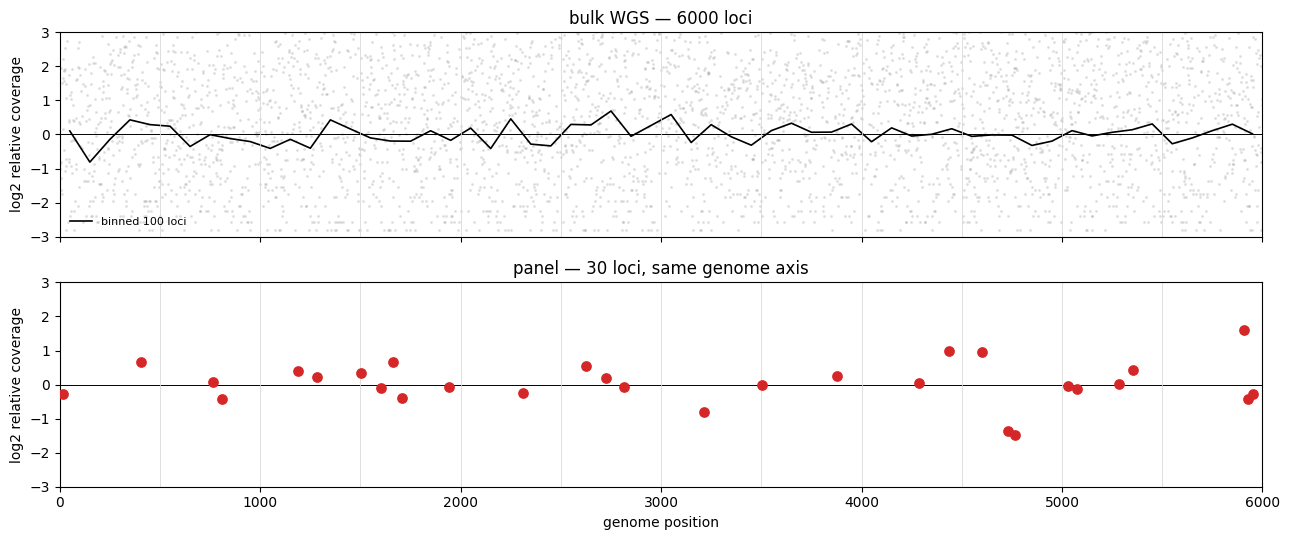

,clone-defining SNVs,on the panel
clone,,
clone_1,0,0
clone_2,0,0
clone_3,2,0
clone_4,0,0
clone_5,1,0
clone_6,0,0
clone_7,0,0
clone_8,11,0
clone_9,2,0


clone-defining sites on the panel: 1 of 21
truncal driver hits on the panel: 2 of 2


In [12]:
# raw relative coverage, in log2 — what you see before anyone tells you the capture efficiencies
def rel_log2(a):
    c = a.observed_data["coverage"].values.astype(float)
    return np.log2((c + 0.5) / np.median(c[c > 0]))

fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
axes[0].scatter(np.arange(adata.n_vars), rel_log2(wgs), s=1.5, alpha=0.2, c="0.6")
cw = binmean(wgs.observed_data["coverage"].values.astype(float))
axes[0].plot(centre, np.log2(cw / np.median(cw)), "k-", lw=1.2, label="binned 100 loci")
axes[0].legend(fontsize=8, frameon=False, loc="lower left")
axes[0].set_ylabel("log2 relative coverage"); axes[0].set_title("bulk WGS — 6000 loci")
axes[1].scatter(panel_idx, rel_log2(panel), s=45, c="C3", zorder=3)
axes[1].set_ylabel("log2 relative coverage"); axes[1].set_title("panel — 30 loci, same genome axis")
axes[1].set_xlabel("genome position")
for ax in axes:
    ax.axhline(0, color="k", lw=0.7)
    for s in np.arange(1, 12) * 500: ax.axvline(s, color="0.85", lw=0.6)
    ax.set_ylim(-3, 3); ax.set_xlim(0, adata.n_vars)
plt.tight_layout(); plt.show()

covered = set(panel_idx.tolist())
rows = []
for lab, sites in defining.items():
    rows.append({"clone": lab, "clone-defining SNVs": len(sites),
                 "on the panel": sum(int(s) in covered for s in sites)})
hit = pd.DataFrame(rows).set_index("clone")
display(hit)
uniq = np.flatnonzero(V.clone_defining)
print(f"clone-defining sites on the panel: {sum(int(s) in covered for s in uniq)} of {len(uniq)}")
print(f"truncal driver hits on the panel: {sum(int(s) in covered for s in truncal_drivers)} of {len(truncal_drivers)}")

The panel catches the trunk — both transforming driver hits are on it, by construction — and
one clone-defining mutation out of twenty-one. Clone-defining variants sit in whatever gene the
lineage happened to hit, and a 30-gene design covering 0.5% of the genome will not have guessed
them; half the clones here have no defining SNV to catch in the first place. A panel tells you what
the tumour is. It does not tell you how many clones it has.

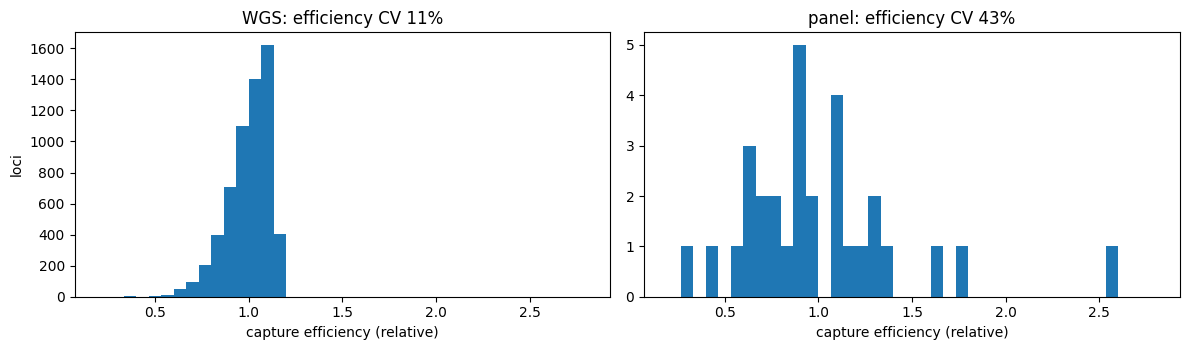

WGS    mean     100x  coverage CV 1.73  = 17x what sampling noise alone would give
panel  mean    1500x  coverage CV 0.46  = 18x what sampling noise alone would give

loci per segment — WGS 500, panel 1-5


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharex=True)
for ax, (nm, a) in zip(axes, [("WGS", wgs), ("panel", panel)]):
    eff = a.batch.efficiency
    ax.hist(eff / eff.mean(), bins=np.linspace(0.2, 2.8, 40), color="C0")
    ax.set_xlabel("capture efficiency (relative)")
    ax.set_title(f"{nm}: efficiency CV {eff.std()/eff.mean():.0%}")
axes[0].set_ylabel("loci")
plt.tight_layout(); plt.show()

for nm, a in [("WGS", wgs), ("panel", panel)]:
    c = a.observed_data["coverage"].values.astype(float)
    print(f"{nm:6s} mean {c.mean():7.0f}x  coverage CV {c.std()/c.mean():.2f}  "
          f"= {c.std()/c.mean()*np.sqrt(c.mean()):.0f}x what sampling noise alone would give")
print(f"\nloci per segment — WGS {adata.n_vars // 12}, panel "
      f"{panel.observed_data.groupby('segment').size().min()}-{panel.observed_data.groupby('segment').size().max()}")

Both assays scatter coverage far beyond what sampling noise alone would give. The difference
is **what kind** of scatter. Per-amplicon capture efficiency spreads panel coverage by ~45%, against
~11% for WGS — so nearly all of the panel's imbalance is systematic. It is the same amplicons every
run and it does not shrink as you sequence deeper.

WGS can average its noise away: 500 loci per segment, all sharing one copy number, so the per-locus
scatter cancels. A panel has one to five loci per segment and no idea where the segment boundaries
are, so a 45% efficiency offset is indistinguishable from a real gain. That is why copy-number
calling from a panel is hard, and why panels are used for mutations rather than for CNAs.

## 5. Single-cell DNA

Same tube, one cell at a time. Two things change. Whole-genome amplification spreads reads
**unevenly** across the genome within each cell, and **allelic dropout** loses one of the two
alleles at a locus outright.

Single-cell libraries are shallow, so at the default depth over all 6000 loci the matrix is almost
entirely zeros. Target the loci that matter — clonal, clone-defining and germline sites plus a grid
spanning the genome — and raise the depth.

586 loci x 250 cancer cells


109 of 586 assayed loci carry a variant in at least 2% of these cells


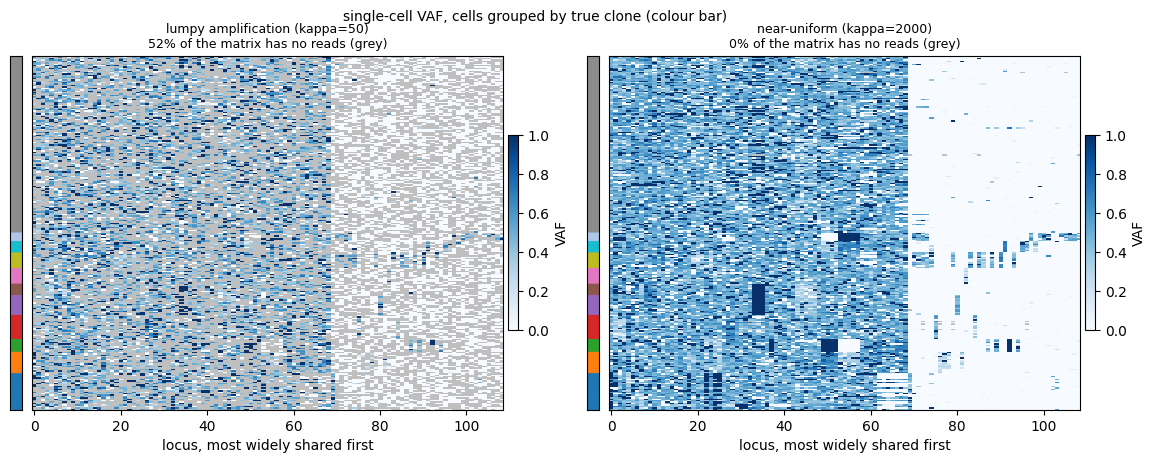

In [14]:
targets = np.unique(np.concatenate([np.flatnonzero(V.truncal), np.flatnonzero(V.clone_defining),
                                     np.flatnonzero(V.germline_het), np.arange(0, adata.n_vars, 12)]))
target_genes = list(genes[targets])
sc_cells = np.random.default_rng(1).choice(cancer_ids, size=250, replace=False)
print(f"{len(target_genes)} loci x {len(sc_cells)} cancer cells")

KAPPAS = {"lumpy amplification (kappa=50)": 50.0, "near-uniform (kappa=2000)": 2000.0}
sc = {k: scDNA(breadth="wgs", seed=4, kappa=v, mu_depth=250.0, target_genes=target_genes)
        .run(sample, cell_subset=sc_cells) for k, v in KAPPAS.items()}

sc_clone = clones.reindex(sc_cells).astype(str).values
order_key = [(c == "other", list(clones.cat.categories).index(c), i) for i, c in enumerate(sc_clone)]
row_order = np.array(sorted(range(len(sc_clone)), key=lambda i: order_key[i]))
sc_colors = np.array([palette[c] for c in sc_clone])

# show the loci that actually carry a variant in these cells, most widely shared first
a0 = sc[list(sc)[0]]
carried = (a0.true_alt_fraction.values > 0).mean(0)
show = np.flatnonzero(carried > 0.02)
show = show[np.argsort(-carried[show])]
cmap = plt.get_cmap("Blues").copy(); cmap.set_bad("0.75")
print(f"{len(show)} of {a0.vaf.shape[1]} assayed loci carry a variant in at least 2% of these cells")

fig = plt.figure(figsize=(14, 4.6))
gs = fig.add_gridspec(1, 5, width_ratios=[0.12, 5, 0.5, 0.12, 5], wspace=0.05)
for j, (nm, a) in enumerate(sc.items()):
    cax = fig.add_subplot(gs[0, 0 + 3 * j])
    cax.imshow(sc_colors[row_order][:, None, :], aspect="auto", origin="lower")
    cax.set_xticks([]); cax.set_yticks([])
    M = np.where(a.coverage.values > 0, a.vaf.values, np.nan)[np.ix_(row_order, show)]
    ax = fig.add_subplot(gs[0, 1 + 3 * j])
    im = ax.imshow(M, aspect="auto", origin="lower", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"{nm}\n{(a.coverage.values == 0).mean():.0%} of the matrix has no reads (grey)",
                 fontsize=9)
    ax.set_xlabel("locus, most widely shared first"); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="VAF")
fig.suptitle("single-cell VAF, cells grouped by true clone (colour bar)", fontsize=10)
plt.show()

Low `kappa` is what whole-genome amplification does: a few loci soak up the reads and most of
the matrix has none. Raise it and the same cells and the same biology become readable. (`kappa` is
the total concentration of the read-spreading distribution, so what counts as "low" depends on how
many loci you assay — over the ~600 here, 50 is lumpy and 2000 is close to uniform.)

### Coverage against the true copy number of exactly these cells

`assay.true_cn` is the copy number of the very cells that were assayed. Binning by chromosome
segment — what a single-cell copy-number caller does — shows how much of the CN signal survives
each amplification regime.

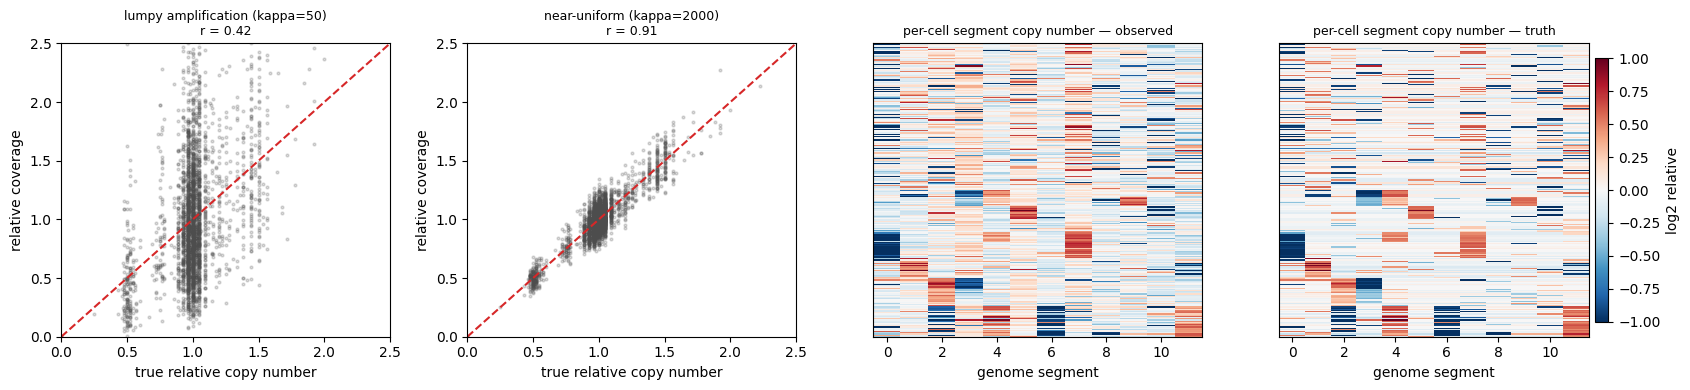

In [15]:
seg_of = np.array([int(g.split("_")[1]) for g in sc[list(sc)[0]].genes])

def by_segment(M, how="sum"):
    out = np.stack([(M[:, seg_of == s].sum(1) if how == "sum" else M[:, seg_of == s].mean(1))
                    for s in range(12)], 1)
    return out / out.mean(1, keepdims=True)

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (nm, a) in zip(axes, sc.items()):
    scov, scn = by_segment(a.coverage.values.astype(float)), by_segment(a.true_cn.values, "mean")
    ax.scatter(scn.ravel(), scov.ravel(), s=4, alpha=0.2, c="0.3")
    ax.plot([0, 2.5], [0, 2.5], "C3--")
    ax.set_xlabel("true relative copy number"); ax.set_ylabel("relative coverage")
    ax.set_title(f"{nm}\nr = {np.corrcoef(scov.ravel(), scn.ravel())[0, 1]:.2f}", fontsize=9)
    ax.set_xlim(0, 2.5); ax.set_ylim(0, 2.5)

a = sc["near-uniform (kappa=2000)"]
for ax, (t, M) in zip(axes[2:], [("observed", by_segment(a.coverage.values.astype(float))),
                                 ("truth", by_segment(a.true_cn.values, "mean"))]):
    im = ax.imshow(np.log2(M[row_order] + 1e-3), aspect="auto", origin="lower", cmap="RdBu_r",
                   vmin=-1, vmax=1, interpolation="nearest")
    ax.set_xlabel("genome segment"); ax.set_yticks([])
    ax.set_title(f"per-cell segment copy number — {t}", fontsize=9)
fig.colorbar(im, ax=axes[3], fraction=0.04, pad=0.02, label="log2 relative")
plt.tight_layout(); plt.show()

Under lumpy amplification the copy-number signal is buried. Under near-uniform coverage it
comes back — and the per-cell profile shows exactly the gains and losses that the bulk log2 ratio in
section 3 averaged into a flat line.

### Allelic dropout

At a heterozygous locus, dropout loses one of the two alleles before amplification, so the cell
reads as homozygous — either all reference (the variant vanishes) or all alt (it looks homozygous).
`assay.ado_mask` records which cell/locus pairs it happened to.

dropout rate: 0.20 set, 0.20 realised at het loci
clonal het locus G_8_131: balanced in 88% of cells


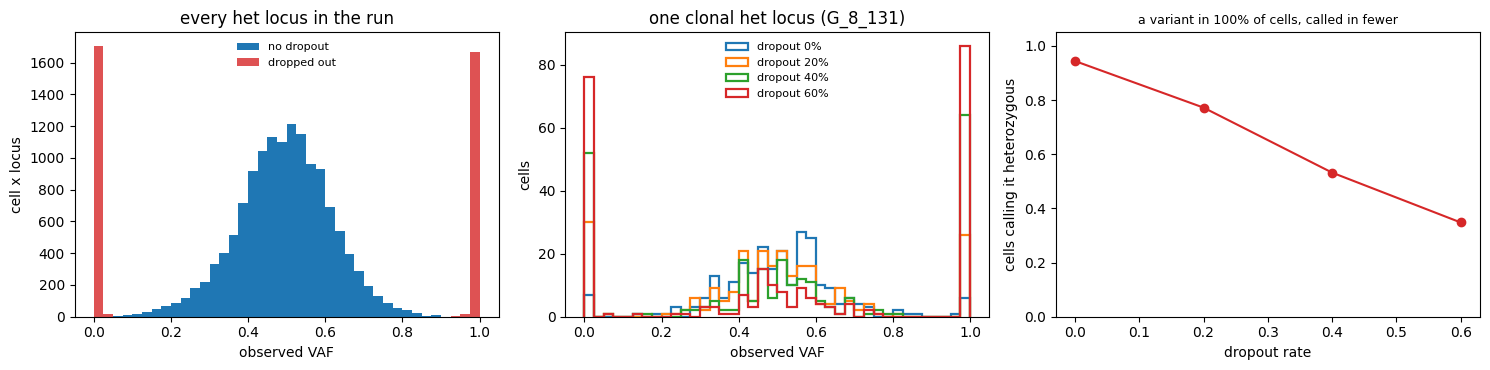

In [16]:
a = sc["near-uniform (kappa=2000)"]
het = (a.true_alt_fraction.values > 0) & (a.true_alt_fraction.values < 1)
covered = a.coverage.values > 0
print(f"dropout rate: {a.hypers.ado_rate:.2f} set, {a.ado_mask.values[het].mean():.2f} realised at het loci")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
bins = np.linspace(0, 1, 41)
m = het & covered
axes[0].hist(a.vaf.values[m & ~a.ado_mask.values], bins=bins, color="C0", label="no dropout")
axes[0].hist(a.vaf.values[m & a.ado_mask.values], bins=bins, color="C3", alpha=0.8, label="dropped out")
axes[0].set_title("every het locus in the run"); axes[0].set_xlabel("observed VAF")
axes[0].set_ylabel("cell x locus"); axes[0].legend(fontsize=8, frameon=False)

# one truly clonal het locus: a germline variant, on one copy of two in every cell
gh = [g for g in a.genes if V.loc[g, "germline_het"]]
frac_half = {g: float(np.mean(np.abs(a.true_alt_fraction[g] - 0.5) < 0.02)) for g in gh}
locus = max(frac_half, key=frac_half.get)
print(f"clonal het locus {locus}: balanced in {frac_half[locus]:.0%} of cells")

rates, het_called = [0.0, 0.2, 0.4, 0.6], []
for ado in rates:
    one = scDNA(breadth="panel", seed=9, ado_rate=ado, mu_depth=60.0,
                target_genes=[locus]).run(sample, cell_subset=sc_cells)
    v1 = one.vaf.values.ravel()
    axes[1].hist(v1, bins=bins, histtype="step", lw=1.6, label=f"dropout {ado:.0%}")
    het_called.append(float(np.mean((v1 > 0.1) & (v1 < 0.9))))
axes[1].set_xlabel("observed VAF"); axes[1].set_ylabel("cells")
axes[1].set_title(f"one clonal het locus ({locus})"); axes[1].legend(fontsize=8, frameon=False)

axes[2].plot(rates, het_called, "o-", color="C3")
axes[2].set_ylim(0, 1.05); axes[2].set_xlabel("dropout rate")
axes[2].set_ylabel("cells calling it heterozygous")
axes[2].set_title("a variant in 100% of cells, called in fewer", fontsize=9)
plt.tight_layout(); plt.show()

Without dropout a clonal het locus reads at 0.5 in every cell. With dropout, mass moves out
of the middle and into 0 and 1 in proportion to the rate — a variant that is genuinely in 100% of
cells is *called* in only some of them. Variant callers that treat a 0 as "absent" turn this into
false phylogenetic structure, which is why single-cell tree builders model dropout explicitly.

### Do the clones come back out?

Cluster the VAF matrix, and separately the segment-level coverage, then score against
`clones_from_clades` with the adjusted Rand index. Cells on the ancestral backbone (`other`) have no
clone to recover, so they are left out of the score.

In [17]:
named = sc_clone != "other"
k = len(set(sc_clone[named]))
rows = []
for nm, a in sc.items():
    cov = a.coverage.values.astype(float)
    scov = np.stack([cov[:, seg_of == s].sum(1) for s in range(12)], 1)
    scov = np.log2(scov / scov.sum(1, keepdims=True) * 12 + 0.05)
    for what, M in [("VAF", a.vaf.values), ("segment coverage", scov)]:
        pred = AgglomerativeClustering(n_clusters=k).fit_predict(M[named])
        rows.append({"run": nm, "features": what, "ARI": adjusted_rand_score(sc_clone[named], pred)})
score = pd.DataFrame(rows).pivot(index="features", columns="run", values="ARI").round(2)
display(score)
print(f"{named.sum()} of {len(sc_clone)} cells belong to one of {k} named clones")

run,lumpy amplification (kappa=50),near-uniform (kappa=2000)
features,,
VAF,0.05,0.44
segment coverage,0.08,0.42


125 of 250 cells belong to one of 10 named clones


Under lumpy amplification the clustering is noise. With usable coverage both readouts recover
the clones partially and to about the same degree — the VAFs from the lineage-specific variants, the
coverage from the copy-number differences. Neither is close to perfect, and the reasons are all in
section 1: half the clones differ by copy number alone, dropout erases a fifth of the het calls, and
ten clones are separated by 21 variants spread over hundreds of loci.

## 6. Fitting the technical parameters to real data

You would not hand-set dropout or the read-spread concentration for a new dataset. `estimate_dna`
fits them from counts — coverage, alt counts, and a copy-number call to condition on —
and `estimate_dna_from_assay` pulls those straight off a run assay.

It is explicit about what it did **not** fit. Dropout and the allele-balance concentration only
exist in single-cell data, so on bulk they are carried from the protocol preset. The doublet rate is
not identifiable from counts at all, ever. `fitted` lists what was actually learned.

In [18]:
est_bulk = estimate_dna_from_assay(wgs)
est_sc = estimate_dna_from_assay(sc["near-uniform (kappa=2000)"])

def row(est, truth):
    t = truth.to_dict()
    h = est.hypers.to_dict()
    keys = [k for k in h if isinstance(h[k], float)]
    return pd.DataFrame({"generated with": [t.get(k) for k in keys],
                         "estimate": [round(float(h[k]), 4) for k in keys],
                         "fitted from data": [k in est.fitted for k in keys]}, index=keys)

print("BULK WGS"); display(row(est_bulk, wgs.hypers))
print("SINGLE CELL"); display(row(est_sc, sc["near-uniform (kappa=2000)"].hypers))
print("bulk  fitted:", est_bulk.fitted)
print("sc    fitted:", est_sc.fitted)

BULK WGS


,generated with,estimate,fitted from data
mu_depth,100.000,100.0000,True
kappa,2000.000,2017.7589,True
nb_dispersion,0.100,0.1000,False
gc_curve_sigma,0.200,0.0606,True
mappability_sigma,0.100,0.1000,False
capture_sigma,0.000,0.0000,False
error_rate,0.001,0.0009,True
depth_batch_sigma,0.050,0.0500,False
ado_rate,0.000,0.0000,False
beta_binom_conc,200.000,200.0000,False


SINGLE CELL


,generated with,estimate,fitted from data
mu_depth,250.000,250.0000,True
kappa,2000.000,2002.2176,True
nb_dispersion,0.500,0.5000,False
gc_curve_sigma,0.200,0.1540,True
mappability_sigma,0.100,0.1000,False
capture_sigma,0.000,0.0000,False
error_rate,0.001,0.0011,True
depth_batch_sigma,0.050,0.0500,False
ado_rate,0.200,0.2001,True
beta_binom_conc,30.000,18.3772,True


bulk  fitted: ['mu_depth', 'gc_curve_sigma', 'kappa', 'error_rate', 'ffpe_ct_rate']
sc    fitted: ['mu_depth', 'gc_curve_sigma', 'kappa', 'error_rate', 'ffpe_ct_rate', 'ado_rate', 'beta_binom_conc']


Depth, the read-spread concentration and the error rate come back close. The GC curve is
under-estimated: copy number and GC content are partly confounded, and the fit conditions on the
copy-number call. Dropout comes back almost exactly, but only from the single-cell run — on bulk it
is a preset value wearing a fitted label's clothes, and the `fitted` list says so. The allele-balance
concentration is low (18 against 30), which is what happens when dropout and overdispersion both
push mass to the edges of the allele-fraction distribution.

`est.dna_kwargs()` splats straight back into `bulkDNA` / `scDNA`, so a fit on a real dataset
becomes a simulator matched to that protocol.

## What to take away

* **Purity first.** A whole-lesion dissociation was 23% cancer. Germline heterozygous sites read at
  0.5 whatever the mixture, which is what makes purity estimable at all.
* **Then multiplicity.** Half these cells are post-whole-genome-doubling, so truncal variants sit on
  ~1.5 copies and the naive clonal peak lands at 1.5 instead of 1.0. Correcting for multiplicity
  fixes it, and fixes the purity estimate with it.
* **Bulk sees the trunk.** At 100x and 23% purity, subclonal variants are below the noise, and the
  copy-number profile is flat because the CNAs are subclonal and average out.
* **A panel is for mutations.** It caught both transforming drivers and 1 of the 21 clone-defining
  variants, and its systematic per-amplicon coverage spread plus one-to-five loci per segment make
  copy-number calling from it hopeless.
* **Single cell trades noise for resolution.** Amplification lumpiness and allelic dropout are the
  two dominant artifacts; with usable coverage, per-cell copy number recovers what bulk averaged
  away and the clones partially cluster back out.